# PS-MNIST Model Comparison: S4 vs LMU Across Data Fractions

This notebook compares S4 and LMU models trained on different fractions of the PS-MNIST dataset.

**Objectives:**
- Compare S4 vs LMU performance across different data sizes
- Analyze data efficiency (which model learns better with less data)
- Visualize learning curves
- Use **test set metrics** for final evaluation
- Identify the best model/fraction combination

**Fractions tested:** 10%, 25%, 50%, 100%


In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

project_root = Path.cwd().parent.parent.parent
sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

Project root: /Users/glbrlb/PycharmProjects/Msc/LMU_S4


## Load Test Results

Load test_results.json from each run folder for both S4 and LMU models across all data fractions.


In [4]:
from src.eval.compare import load_all_experiments

base_dir = "./runs"
models = ['s4', 'lmu']
fractions = [0.1, 0.25, 0.5, 1.0]
task_name = "psmnist"

print("="*60)
print("LOADING PS-MNIST EXPERIMENT RESULTS")
print("="*60)
print()

all_results = load_all_experiments(
    base_dir=base_dir,
    models=models,
    fractions=fractions,
    task_name=task_name
)

print()
print("="*60)
print("LOADING COMPLETE")
print("="*60)

for model in models:
    n_loaded = sum(1 for results in all_results[model].values() if results)
    print(f"{model.upper()}: Loaded {n_loaded}/{len(fractions)} experiments")

LOADING PS-MNIST EXPERIMENT RESULTS

Loading S4 @ 10%: psmnist_s4_task_frac_10
Loading S4 @ 25%: psmnist_s4_task_frac_25
Loading S4 @ 50%: psmnist_s4_task_frac_50
Loading S4 @ 100%: psmnist_s4_task
Loading LMU @ 10%: psmnist_lmu_task_frac_10
Loading LMU @ 25%: psmnist_lmu_task_frac_25
Loading LMU @ 50%: psmnist_lmu_task_frac_50
Loading LMU @ 100%: psmnist_lmu_task

LOADING COMPLETE
S4: Loaded 4/4 experiments
LMU: Loaded 4/4 experiments


## Results Summary Table


In [7]:
from src.eval.compare import create_test_comparison_table

print()

test_comparison_df = create_test_comparison_table(
    all_results,
    metrics=['accuracy', 'loss']
)

pd.options.display.float_format = '{:.4f}'.format


print("\n" + "="*60)
print("BEST MODEL PER DATA FRACTION")
print("="*60)
for pct in sorted(test_comparison_df['data_pct'].unique()):
    subset = test_comparison_df[test_comparison_df['data_pct'] == pct]
    best_idx = subset['accuracy'].idxmax()
    best_row = subset.loc[best_idx]
    print(f"\n{pct}% data: {best_row['model']} (Accuracy: {best_row['accuracy']*100:.2f}%)")

print()
test_comparison_df



BEST MODEL PER DATA FRACTION

10% data: LMU (Accuracy: 91.54%)

25% data: LMU (Accuracy: 94.14%)

50% data: LMU (Accuracy: 94.75%)

100% data: LMU (Accuracy: 96.24%)



,model,data_pct,accuracy,loss,num_samples
0,LMU,10,0.9154,0.2986,10000
1,LMU,25,0.9414,0.2142,10000
2,LMU,50,0.9475,0.1811,10000
3,LMU,100,0.9624,0.1499,10000
4,S4,10,0.7411,0.7622,10000
5,S4,25,0.8758,0.4087,10000
6,S4,50,0.9200,0.2769,10000
7,S4,100,0.9166,0.2822,10000


## Visualization: Test Accuracy Comparison

Compare test accuracy of S4 and LMU across different data fractions.


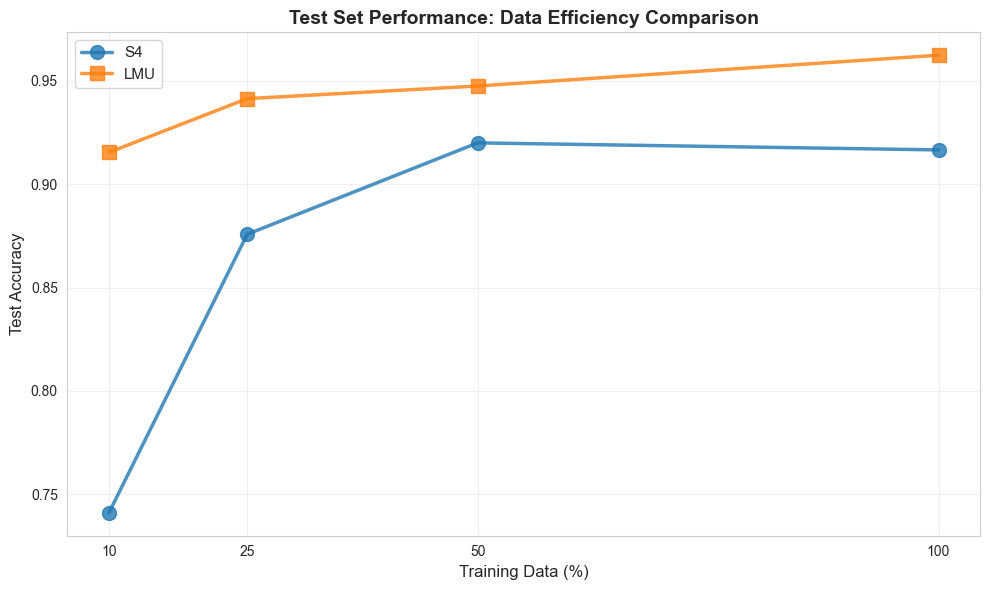

In [8]:
from src.eval.compare import plot_test_data_efficiency

plot_test_data_efficiency(
    all_results,
    metric_key='accuracy',
    ylabel='Test Accuracy'
)

## Visualization: Test Loss Comparison

Compare test loss of S4 and LMU across different data fractions.


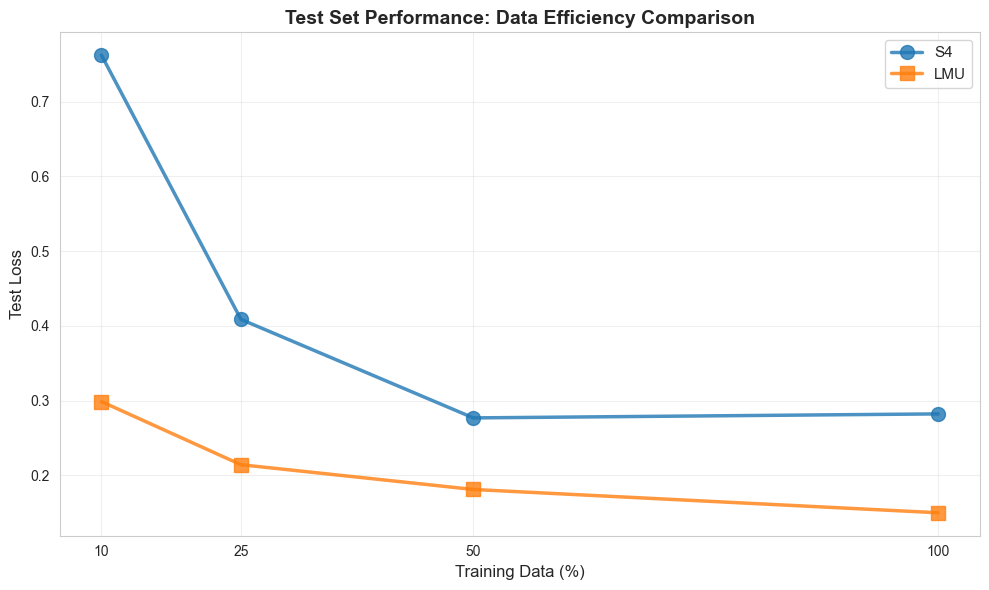

In [9]:
plot_test_data_efficiency(
    all_results,
    metric_key='loss',
    ylabel='Test Loss'
)

## Bar Chart Comparison

Side-by-side comparison of test accuracy for each data fraction.


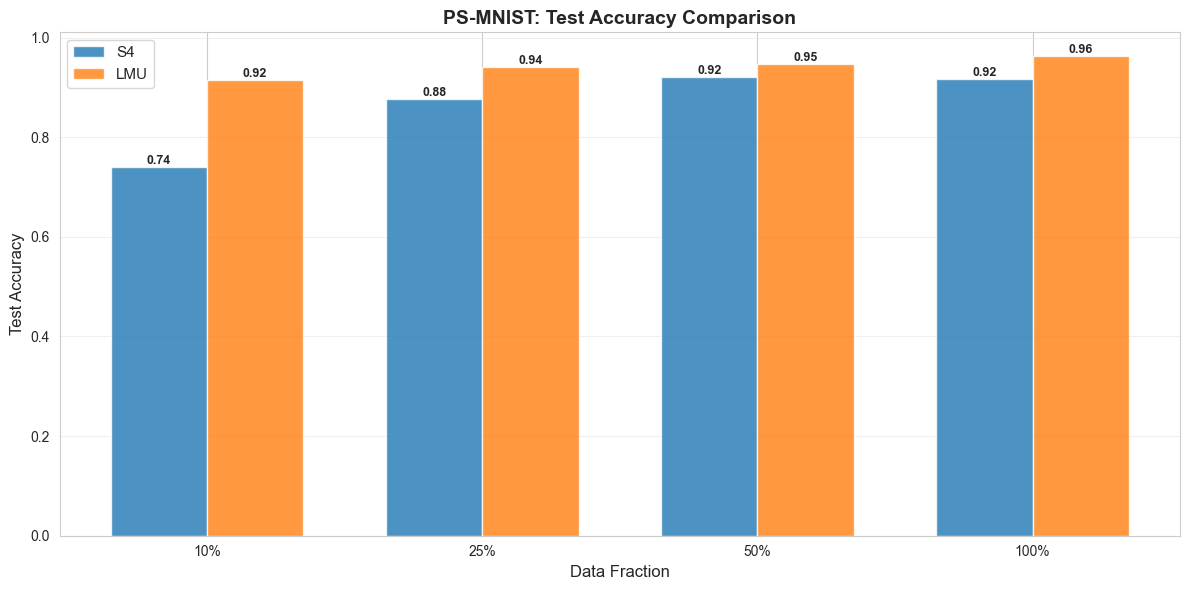

In [10]:
from src.eval.compare import plot_test_metric_comparison

plot_test_metric_comparison(
    all_results,
    metric_key='accuracy',
    title='PS-MNIST: Test Accuracy Comparison',
    ylabel='Test Accuracy',
)

### Heatmap Visualization

Visual comparison of test accuracy across models and data fractions.


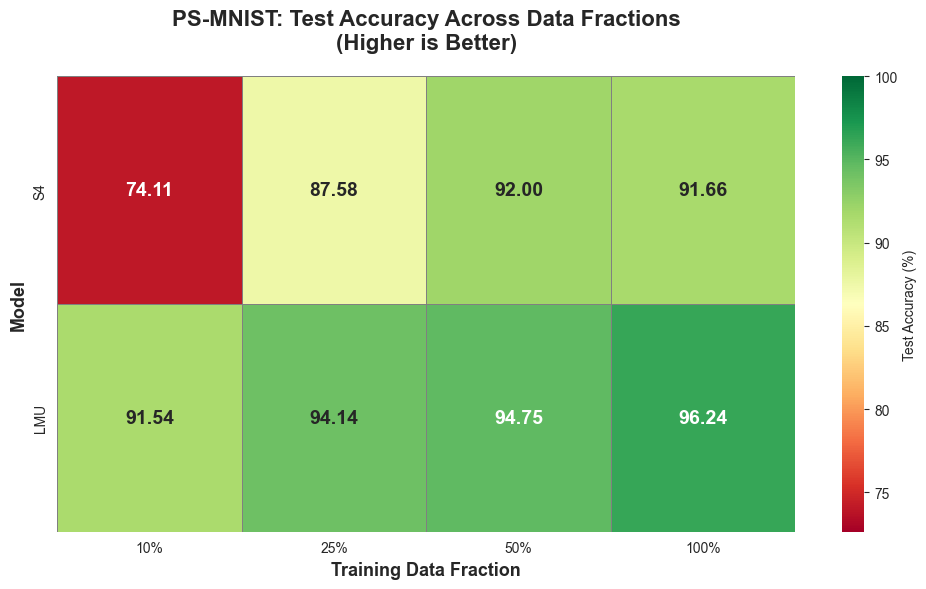

In [11]:
import numpy as np

heatmap_data = {}

for model in models:
    heatmap_data[model.upper()] = {}

    for frac in fractions:
        frac_results = all_results[model].get(frac, {})
        if frac_results and 'accuracy' in frac_results:
            # Convert to percentage
            heatmap_data[model.upper()][frac] = frac_results['accuracy'] * 100
        else:
            heatmap_data[model.upper()][frac] = np.nan

fig, ax = plt.subplots(figsize=(10, 6))

acc_matrix = pd.DataFrame(heatmap_data).T
acc_matrix = acc_matrix[[0.1, 0.25, 0.5, 1.0]]  # Reorder columns
acc_matrix.columns = ['10%', '25%', '50%', '100%']

sns.heatmap(acc_matrix, annot=True, fmt='.2f', cmap='RdYlGn',
            cbar_kws={'label': 'Test Accuracy (%)'}, ax=ax,
            vmin=acc_matrix.min().min() * 0.98, vmax=100,
            linewidths=0.5, linecolor='gray', annot_kws={'size': 14, 'weight': 'bold'})

ax.set_title('PS-MNIST: Test Accuracy Across Data Fractions\n(Higher is Better)',
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Training Data Fraction', fontsize=13, fontweight='bold')
ax.set_ylabel('Model', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()